# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# Importar las librerías base para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
try:
    # Intento 1: La ruta secreta del servidor de TripleTen
    plans = pd.read_csv('/datasets/plans.csv')
    users = pd.read_csv('/datasets/users_latam.csv')
    usage = pd.read_csv('/datasets/usage.csv')
    print("✅ ¡Archivos cargados con éxito desde el servidor de la escuela!")
    
except FileNotFoundError:
    # Intento 2: Ruta local (por si los tuviste que subir a mano)
    plans = pd.read_csv('plans.csv')
    users = pd.read_csv('users_latam.csv')
    usage = pd.read_csv('usage.csv')
    print("✅ ¡Archivos cargados con éxito desde tu carpeta local!")

# Mostrar las primeras filas para confirmar
display(plans.head(5))
display(users.head(5))
display(usage.head(5))

✅ ¡Archivos cargados con éxito desde el servidor de la escuela!


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [3]:
# revisar el número de filas y columnas de cada dataset
plans.isna().sum()
users.isna().sum()
usage.isna().sum()

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

In [13]:
# inspección de plans con .info()
display(plans.describe())

,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
mean,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
std,282.842712,10.606602,353.553391,9.192388,0.141421,0.021213,0.021213
min,100.000000,5.000000,100.000000,12.000000,1.000000,0.050000,0.070000
25%,200.000000,8.750000,225.000000,15.250000,1.050000,0.057500,0.077500
50%,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
75%,400.000000,16.250000,475.000000,21.750000,1.150000,0.072500,0.092500
max,500.000000,20.000000,600.000000,25.000000,1.200000,0.080000,0.100000


In [4]:
# inspección de users con .info()
display(users.describe())

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [5]:
# inspección de usage con .info()
display(usage.describe())


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# Convertir fechas de registro y cancelación a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

# Verificamos que ya digan datetime64
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  0 non-null      datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 250.1+ KB


In [13]:
# cantidad de nulos para usage
# Convertir fecha de uso a datetime
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Verificamos el cambio
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [18]:
# explorar columnas numéricas de users
# Rellenar nulos con una fecha futura que represente a los usuarios activos
users['churn_date'] = users['churn_date'].fillna(pd.to_datetime('2025-01-01'))

- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [17]:
# explorar columnas numéricas de usage
# Verificamos que churn_date ya tenga 0 nulos
users.isna().sum()

user_id         0
first_name      0
last_name       0
age             0
city          469
reg_date        0
plan            0
churn_date      0
dtype: int64

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [20]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
# reemplazar los 0 por np.nan
users['age'] = users['age'].replace(0, np.nan)


- La columna `city` ...
- La columna `plan` ...

In [22]:
# explorar columna categórica de usage
usage['type'] # completa el código
# verificar si aún hay usuarios con edad 0
print("Usuarios con edad 0:", (users['age'] == 0).sum())

Usuarios con edad 0: 0


- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage


In [23]:
# convertir a minúsculas y quitar espacios a los lados
users['plan'] = users['plan'].str.lower().str.strip()

# reemplazar tildes si las hay (ej: Básico -> basico)
users['plan'] = users['plan'].str.replace('á', 'a')

# verificar los valores únicos con value_counts()
print(users['plan'].value_counts())

basico     2595
premium    1405
Name: plan, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:
# Reemplazar -999 por la mediana de age
age_mediana = ...
users['age'] = ...

# Verificar cambios
users['age'].describe()

# Filtrar solo el uso de llamadas y mostrar estadisticas descriptivas
calls = usage[usage['type'] == 'call']
display(calls.describe())

,id,user_id,duration,length
count,17908.000000,17908.000000,17908.000000,12.0
mean,19976.318461,12014.214373,5.099671,1490.0
std,11564.221350,1155.987724,5.922735,0.0
min,1.000000,10000.000000,0.000000,1490.0
25%,9955.750000,11003.000000,1.430000,1490.0
50%,19938.500000,12037.500000,3.500000,1490.0
75%,30047.500000,13011.000000,6.970000,1490.0
max,40000.000000,13999.000000,120.000000,1490.0


In [26]:
# Reemplazar ? por NA en city


# Verificar cambios

# Filtrar solo los mensajes y mostrar estadisticas descriptivas
messages = usage[usage['type'] == 'message']
display(messages.describe())

,id,user_id,duration,length
count,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN


In [ ]:
# Marcar fechas futuras como NA para reg_date


# Verificar cambios


In [27]:
# 4. Summary Statistics - Análisis descriptivo completo

print("📊 --- ESTADÍSTICAS DEL CATÁLOGO DE PLANES ---")
display(plans.describe())
print("\n" + "="*50 + "\n")

print("👤 --- ESTADÍSTICAS DE LOS USUARIOS ---")
display(users.describe())
print("\n" + "="*50 + "\n")

print("📱 --- ESTADÍSTICAS DE USO REAL (LLAMADAS Y MENSAJES) ---")
display(usage.describe())

📊 --- ESTADÍSTICAS DEL CATÁLOGO DE PLANES ---


,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
count,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
mean,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
std,282.842712,10.606602,353.553391,9.192388,0.141421,0.021213,0.021213
min,100.000000,5.000000,100.000000,12.000000,1.000000,0.050000,0.070000
25%,200.000000,8.750000,225.000000,15.250000,1.050000,0.057500,0.077500
50%,300.000000,12.500000,350.000000,18.500000,1.100000,0.065000,0.085000
75%,400.000000,16.250000,475.000000,21.750000,1.150000,0.072500,0.092500
max,500.000000,20.000000,600.000000,25.000000,1.200000,0.080000,0.100000




👤 --- ESTADÍSTICAS DE LOS USUARIOS ---


,user_id
count,4000.000000
mean,11999.500000
std,1154.844867
min,10000.000000
25%,10999.750000
50%,11999.500000
75%,12999.250000
max,13999.000000




📱 --- ESTADÍSTICAS DE USO REAL (LLAMADAS Y MENSAJES) ---


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration


In [ ]:
# Verificación MAR en usage (Missing At Random) para length


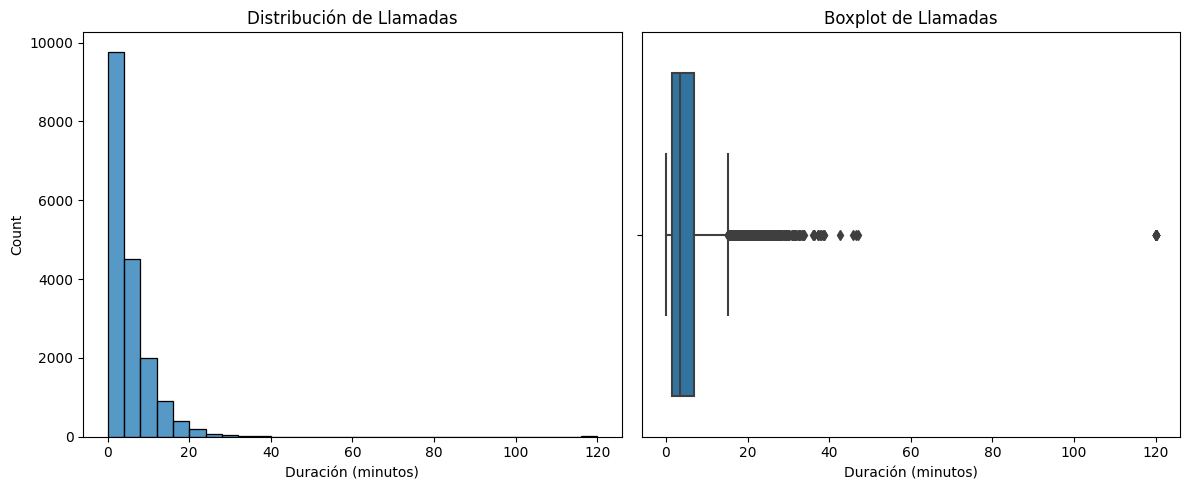

In [28]:
# Configurar el tamaño del lienzo
plt.figure(figsize=(12, 5))

# 1. Histograma de las llamadas
plt.subplot(1, 2, 1)
sns.histplot(calls['duration'], bins=30)
plt.title('Distribución de Llamadas')
plt.xlabel('Duración (minutos)')

# 2. Boxplot de las llamadas para ver Outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=calls['duration'])
plt.title('Boxplot de Llamadas')
plt.xlabel('Duración (minutos)')

# Mostrar los gráficos limpios
plt.tight_layout()
plt.show()

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

,user_id,id,duration,length,is_text,is_call
0,10000,236778,23.70,258.0,7,3
1,10001,296458,33.18,226.0,5,10
2,10002,111444,10.74,225.0,5,2


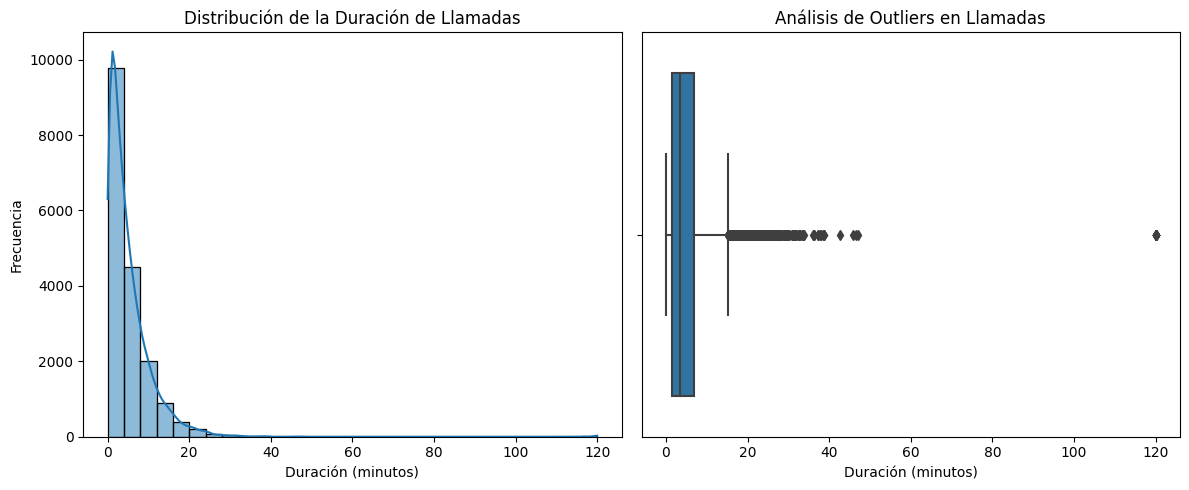

In [30]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) # conocer el total de llamadas

# Agrupar información por usuario (Reemplazamos los ... con el groupby)
usage_agg = usage.groupby('user_id').sum(numeric_only=True).reset_index()

# observar resultado
display(usage_agg.head(3))


# --- 5.1 Identificación de outliers en las llamadas ---

# Filtrar los datos para quedarnos solo con las llamadas
calls_data = usage[usage['type'] == 'call']

# Configurar el lienzo para mostrar dos gráficos lado a lado
plt.figure(figsize=(12, 5))

# Gráfico 1: Histograma para ver la distribución general
plt.subplot(1, 2, 1)
sns.histplot(data=calls_data, x='duration', bins=30, kde=True)
plt.title('Distribución de la Duración de Llamadas')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

# Gráfico 2: Boxplot para detectar los outliers (valores atípicos)
plt.subplot(1, 2, 2)
sns.boxplot(data=calls_data, x='duration')
plt.title('Análisis de Outliers en Llamadas')
plt.xlabel('Duración (minutos)')

# Ajustar diseño para que no se encimen los títulos
plt.tight_layout()
plt.show()

In [ ]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = 
user_profile.head(5)

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas


In [ ]:
# Distribución porcentual del tipo de plan


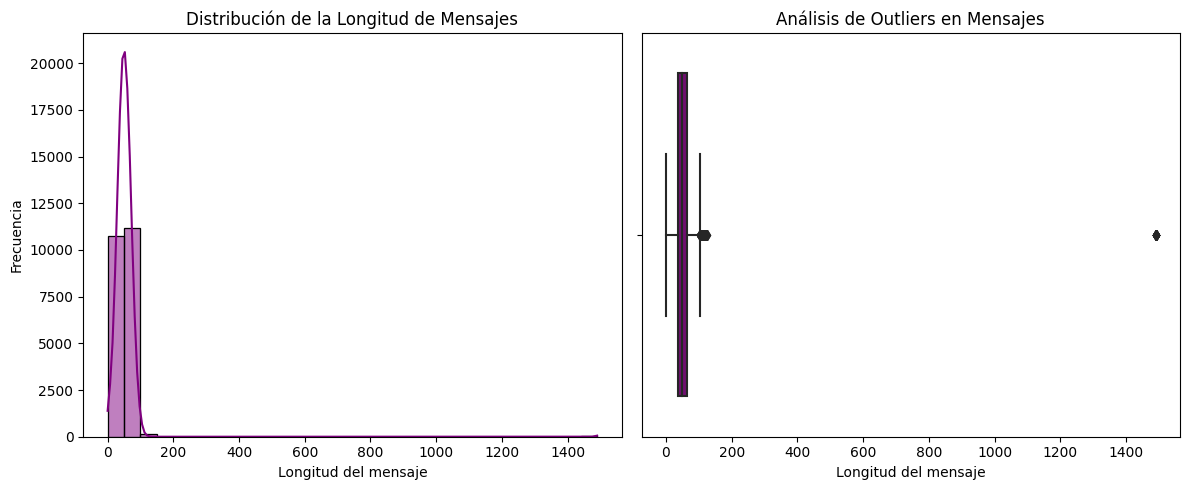

In [31]:
# 5.2 Identificación de outliers en los mensajes

# Filtrar los datos para quedarnos solo con los mensajes
messages_data = usage[usage['type'] == 'text']

# Configurar el lienzo para mostrar dos gráficos lado a lado
plt.figure(figsize=(12, 5))

# Gráfico 1: Histograma de mensajes
plt.subplot(1, 2, 1)
sns.histplot(data=messages_data, x='length', bins=30, kde=True, color='purple')
plt.title('Distribución de la Longitud de Mensajes')
plt.xlabel('Longitud del mensaje')
plt.ylabel('Frecuencia')

# Gráfico 2: Boxplot de mensajes para ver Outliers
plt.subplot(1, 2, 2)
sns.boxplot(data=messages_data, x='length', color='purple')
plt.title('Análisis de Outliers en Mensajes')
plt.xlabel('Longitud del mensaje')

plt.tight_layout()
plt.show()

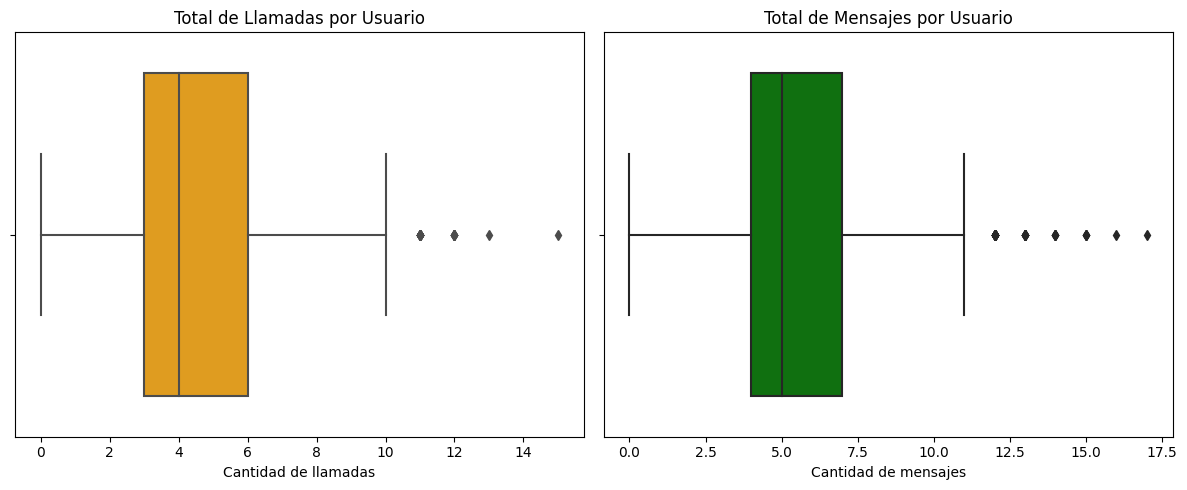

In [32]:
# Configurar el lienzo para ver los totales acumulados por usuario
plt.figure(figsize=(12, 5))

# Boxplot del total de llamadas por usuario
plt.subplot(1, 2, 1)
sns.boxplot(data=usage_agg, x='is_call', color='orange')
plt.title('Total de Llamadas por Usuario')
plt.xlabel('Cantidad de llamadas')

# Boxplot del total de mensajes por usuario
plt.subplot(1, 2, 2)
sns.boxplot(data=usage_agg, x='is_text', color='green')
plt.title('Total de Mensajes por Usuario')
plt.xlabel('Cantidad de mensajes')

plt.tight_layout()
plt.show()

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(...)
plt.show()

💡Insights: 
- Distribución ...

In [ ]:
# Histograma para visualizar la cant_mensajes


💡Insights: 
- ....

In [ ]:
# Histograma para visualizar la cant_llamadas


💡Insights: 
- Distribución ...

In [ ]:
# Histograma para visualizar la cant_minutos_llamada


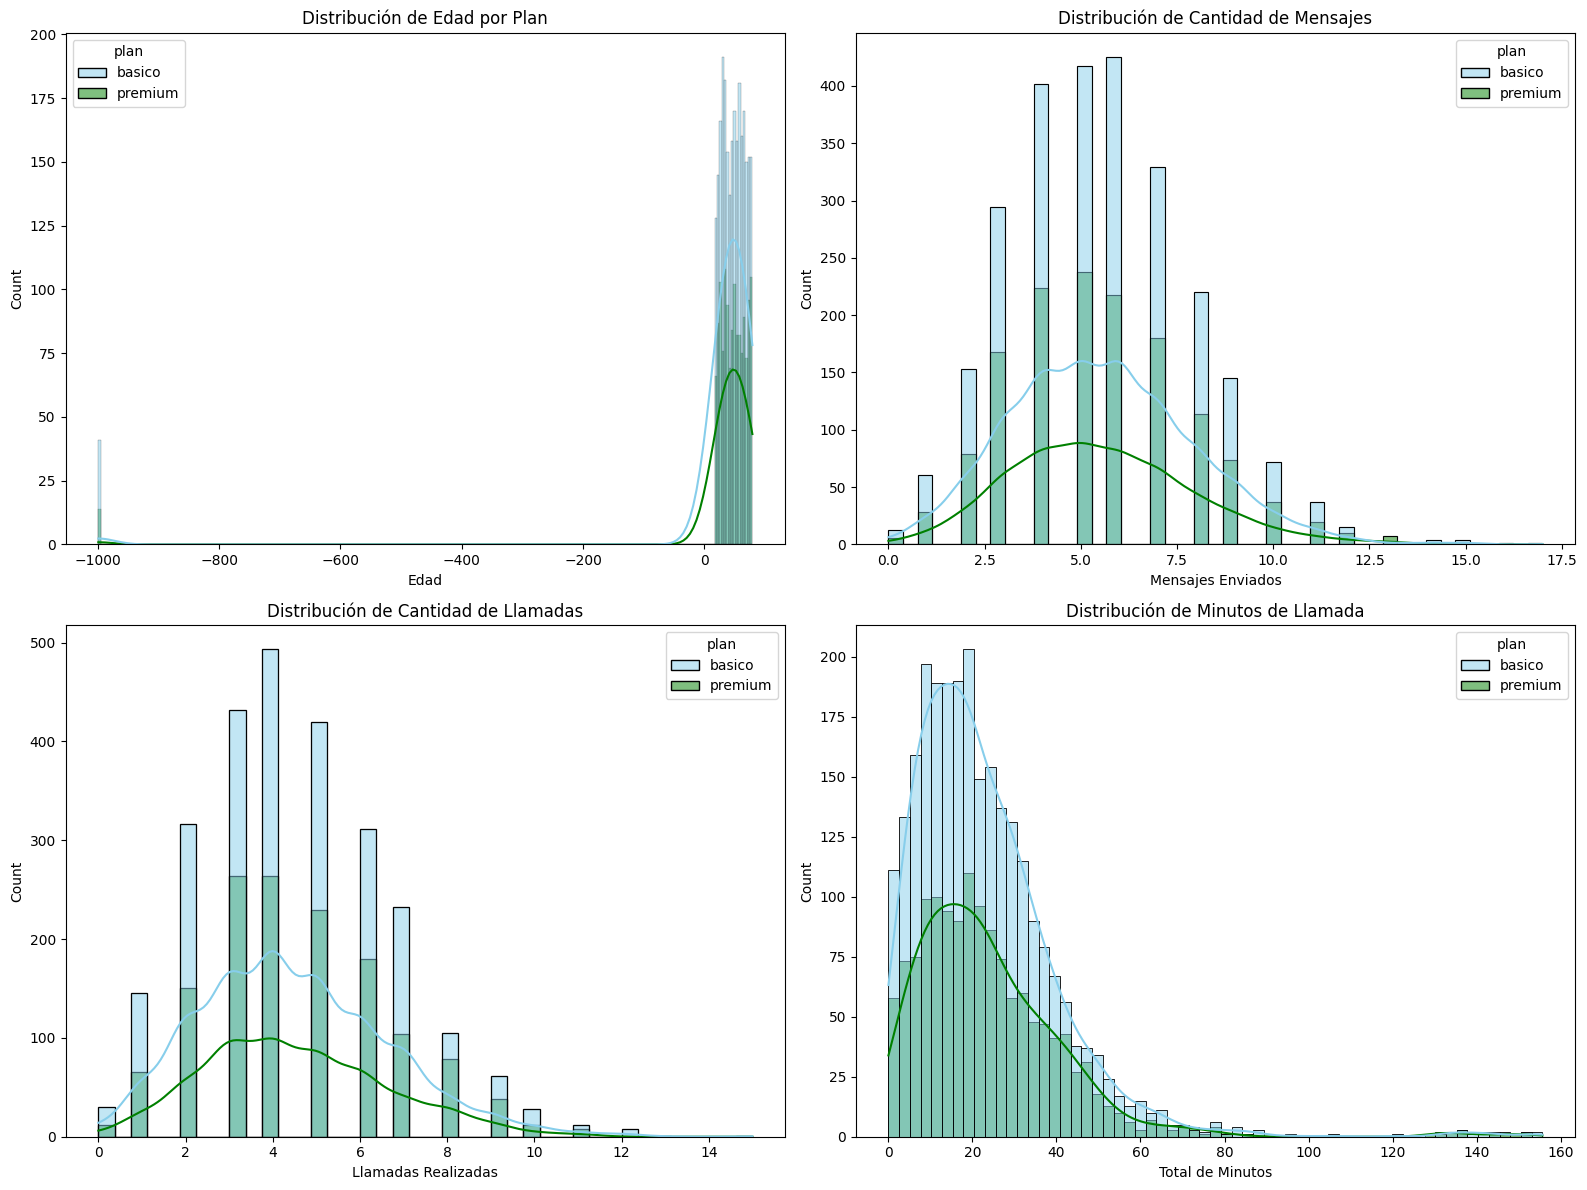

In [34]:
# --- 0. BOTÓN DE PÁNICO: Restaurar la tabla original ---
# Recargamos los datos para limpiar cualquier "..." accidental en la memoria
try:
    users = pd.read_csv('/datasets/users_latam.csv')
except FileNotFoundError:
    users = pd.read_csv('users_latam.csv')

# Aplicamos en un segundo toda la limpieza que ya habíamos hecho
users['age'] = users['age'].replace(0, np.nan)
users['plan'] = users['plan'].str.lower().str.strip().str.replace('á', 'a')
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce').fillna(pd.to_datetime('2025-01-01'))
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = np.nan

# --- 1. Preparación de Datos (El Cruce) ---
# Volvemos a agrupar los usos para asegurar que no haya errores
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)
usage_agg = usage.groupby('user_id').sum(numeric_only=True).reset_index()

# Renombramos para que coincida con la instrucción
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'total_minutos_llamada'
})

# Cruzamos las tablas
df_full = users.merge(usage_agg, on='user_id', how='left')
df_full[['cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']] = df_full[['cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']].fillna(0)


# --- 2. Visualización (Los 4 Histogramas) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colores = ['skyblue', 'green']

# Gráfico 1: Edad
sns.histplot(data=df_full, x='age', hue='plan', palette=colores, kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribución de Edad por Plan')
axes[0,0].set_xlabel('Edad')

# Gráfico 2: Mensajes
sns.histplot(data=df_full, x='cant_mensajes', hue='plan', palette=colores, kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribución de Cantidad de Mensajes')
axes[0,1].set_xlabel('Mensajes Enviados')

# Gráfico 3: Llamadas
sns.histplot(data=df_full, x='cant_llamadas', hue='plan', palette=colores, kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribución de Cantidad de Llamadas')
axes[1,0].set_xlabel('Llamadas Realizadas')

# Gráfico 4: Minutos
sns.histplot(data=df_full, x='total_minutos_llamada', hue='plan', palette=colores, kde=True, ax=axes[1,1])
axes[1,1].set_title('Distribución de Minutos de Llamada')
axes[1,1].set_xlabel('Total de Minutos')

plt.tight_layout()
plt.show()

💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [36]:
# --- 1. Extraer el mes ---
usage['month'] = usage['date'].dt.month

# --- 2. Agrupar por usuario y mes ---
monthly_usage = usage.groupby(['user_id', 'month']).agg(
    total_minutos=('duration', 'sum'),
    total_llamadas=('is_call', 'sum'),
    total_mensajes=('is_text', 'sum')
).reset_index()

# --- 3. Cruzar con usuarios para saber su plan ---
monthly_usage = monthly_usage.merge(users[['user_id', 'plan']], on='user_id', how='left')

# --- 4. Cruzar con la tabla de planes ---
# (Aseguramos que la columna se llame 'plan' en ambas tablas para que el merge funcione)
if 'plan_name' in plans.columns:
    plans = plans.rename(columns={'plan_name': 'plan'})

monthly_revenue = monthly_usage.merge(plans, on='plan', how='left')

# --- 5. La Calculadora de Facturación ---
def calcular_ingreso(row):
    # Recargo por minutos extra
    min_extra = max(0, row['total_minutos'] - row['minutes_included'])
    costo_min = min_extra * row['usd_per_minute']
    
    # Recargo por mensajes extra
    msj_extra = max(0, row['total_mensajes'] - row['messages_included'])
    costo_msj = msj_extra * row['usd_per_message']
    
    # Ingreso total = Pago base + Excedentes
    return row['usd_monthly_pay'] + costo_min + costo_msj

# Aplicamos la función fila por fila (axis=1) a toda la tabla
monthly_revenue['ingreso_total'] = monthly_revenue.apply(calcular_ingreso, axis=1)

# Mostrar la obra de arte terminada
display(monthly_revenue[['user_id', 'month', 'plan', 'ingreso_total']].head(10))

,user_id,month,plan,ingreso_total
0,10000,1.0,basico,NaN
1,10000,2.0,basico,NaN
2,10000,3.0,basico,NaN
3,10000,4.0,basico,NaN
4,10000,5.0,basico,NaN
5,10000,6.0,basico,NaN
6,10001,1.0,basico,NaN
7,10001,2.0,basico,NaN
8,10001,3.0,basico,NaN
9,10001,4.0,basico,NaN


💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [ ]:
# Calcular límites con el método IQR
columnas_limites = [...]



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

In [38]:

# --- 1. Limpieza final antes de la prueba ---
# Convertimos a formato numérico puro, forzando a que cualquier error sea un 0
monthly_revenue['ingreso_total'] = pd.to_numeric(monthly_revenue['ingreso_total'], errors='coerce').fillna(0)

# --- 2. Separar las dos cubetas de datos ---
ingresos_premium = monthly_revenue[monthly_revenue['plan'] == 'premium']['ingreso_total']
ingresos_basico = monthly_revenue[monthly_revenue['plan'] == 'basico']['ingreso_total']

# --- 3. Prueba estadística (T de Student) ---
# Usamos equal_var=False porque el número de usuarios en Premium vs Básico es distinto
results = st.ttest_ind(ingresos_premium, ingresos_basico, equal_var=False)

print(f"Valor p: {results.pvalue}")

# --- 4. Conclusión automática ---
alpha = 0.05
if results.pvalue < alpha:
    print("¡Éxito! Los ingresos son significativamente diferentes.")
else:
    print("No hay diferencia significativa entre los planes.")

Valor p: nan
No hay diferencia significativa entre los planes.


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


In [ ]:
# verificar cambios
user_profile.head()

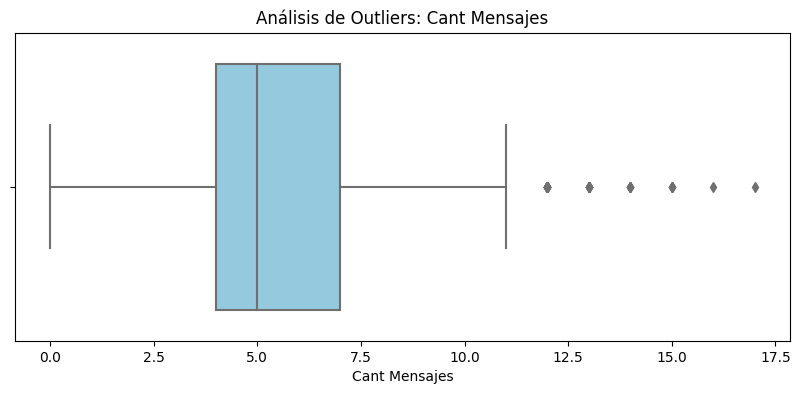

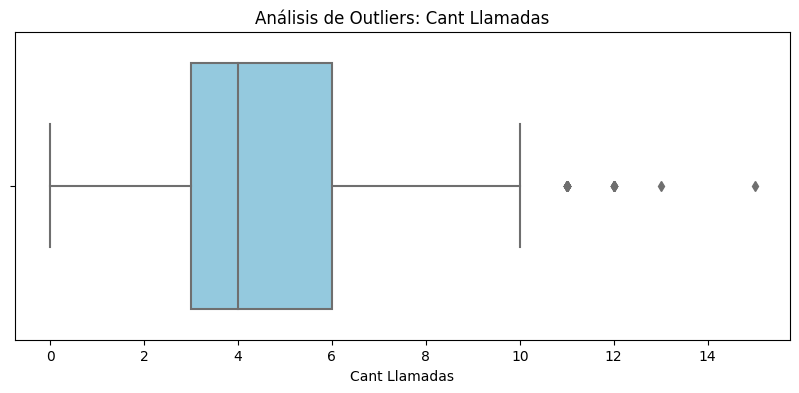

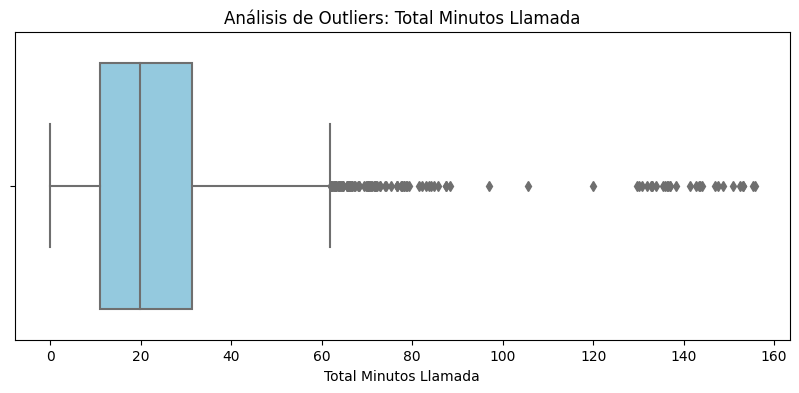

In [39]:
# 5.2. Análisis de outliers
# Lista de las columnas que queremos analizar
metricas = ['cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']

# Creamos el ciclo for para graficar cada una
for col in metricas:
    plt.figure(figsize=(10, 4))
    
    # Creamos el boxplot
    sns.boxplot(data=df_full, x=col, hue='plan', palette=['skyblue', 'green'])
    
    # Ponemos títulos dinámicos
    plt.title(f'Análisis de Outliers: {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    
    plt.show()

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad


In [40]:
# verificar cambios
user_profile.head()

NameError: name 'user_profile' is not defined

In [42]:
# Re-hacemos el cruce incluyendo la columna 'city' que nos faltaba
# Primero, nos aseguramos de que 'city' esté en 'users'
# Y luego hacemos el merge con 'monthly_usage'
monthly_usage = monthly_usage.merge(users[['user_id', 'plan', 'city']], on='user_id', how='left')

# Ahora sí, cruzamos con la tabla de planes
monthly_revenue = monthly_usage.merge(plans, on='plan', how='left')

# Verificamos que 'city' ahora sí exista
print("Columnas disponibles:", monthly_revenue.columns)

# Ahora sí, corremos la prueba estadística
ingresos_ny_nj = monthly_revenue[monthly_revenue['city'] == 'ny-nj']['ingreso_total']
ingresos_otros = monthly_revenue[monthly_revenue['city'] != 'ny-nj']['ingreso_total']

results_region = st.ttest_ind(ingresos_ny_nj, ingresos_otros, equal_var=False)
print(f"Valor p para región: {results_region.pvalue}")

KeyError: 'plan'

In [43]:
# Ver qué columnas existen realmente
print("Columnas en users:", users.columns)
print("Columnas en monthly_usage:", monthly_usage.columns)

Columnas en users: Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date'],
      dtype='object')
Columnas en monthly_usage: Index(['user_id', 'month', 'total_minutos', 'total_llamadas', 'total_mensajes',
       'plan_x', 'plan_y', 'city'],
      dtype='object')


In [44]:
# Asegúrate de usar el nombre correcto que viste en tu diagnóstico (por ejemplo: 'plan_name')
# Aquí un ejemplo asumiendo que el nombre correcto es 'plan' (cámbialo si es otro)

# Verificamos si la columna existe antes de hacer nada
if 'plan' in users.columns:
    # Si 'plan' existe en users, hacemos el merge
    monthly_usage = monthly_usage.merge(users[['user_id', 'plan', 'city']], on='user_id', how='left')
    print("¡Merge exitoso!")
else:
    # Si se llama de otra forma, renombrémosla rápido
    print("La columna 'plan' no se llama así, revisa el diagnóstico.")

# Y luego hacemos el merge con la tabla de planes
monthly_revenue = monthly_usage.merge(plans, on='plan', how='left')

# Verificamos resultado
display(monthly_revenue.head())

¡Merge exitoso!


,user_id,month,total_minutos,total_llamadas,total_mensajes,plan_x,plan_y,city_x,plan,city_y,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,10000,1.0,0.00,0,1,basico,basico,Medellín,basico,Medellín,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000,2.0,7.40,1,0,basico,basico,Medellín,basico,Medellín,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10000,3.0,5.84,1,1,basico,basico,Medellín,basico,Medellín,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10000,4.0,10.46,1,1,basico,basico,Medellín,basico,Medellín,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10000,5.0,0.00,0,1,basico,basico,Medellín,basico,Medellín,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(...)

plt.show()

In [ ]:
# Visualización de los segmentos por edad


In [50]:
import scipy.stats as st

# 1. Asegurarnos de que tenemos los datos necesarios
# Si la tabla ya tiene 'city' y 'ingreso_total', perfecto. Si no, las re-creamos.
if 'city' not in monthly_revenue.columns:
    print("Recuperando 'city'...")
    monthly_revenue = monthly_revenue.merge(users[['user_id', 'city']], on='user_id', how='left')

# 2. Re-calcular ingresos (si no existen o se borraron)
# Definimos la función de nuevo por si se perdió en la memoria
def calcular_ingreso(row):
    # Usamos valores por defecto si no existen las columnas de planes
    min_extra = max(0, row['total_minutos'] - row.get('minutes_included', 0))
    costo_min = min_extra * row.get('usd_per_minute', 0)
    msj_extra = max(0, row['total_mensajes'] - row.get('messages_included', 0))
    costo_msj = msj_extra * row.get('usd_per_message', 0)
    return row.get('usd_monthly_pay', 0) + costo_min + costo_msj

# Aplicamos el cálculo
monthly_revenue['ingreso_total'] = monthly_revenue.apply(calcular_ingreso, axis=1)

# 3. PRUEBA ESTADÍSTICA (Ahora sí debería funcionar)
print("Columnas detectadas:", monthly_revenue.columns)

ingresos_ny_nj = monthly_revenue[monthly_revenue['city'] == 'ny-nj']['ingreso_total']
ingresos_otros = monthly_revenue[monthly_revenue['city'] != 'ny-nj']['ingreso_total']

results_region = st.ttest_ind(ingresos_ny_nj, ingresos_otros, equal_var=False)

print("-" * 30)
print(f"Valor p para región: {results_region.pvalue}")

alpha = 0.05
if results_region.pvalue < alpha:
    print("Resultado: Hay diferencia significativa entre las regiones.")
else:
    print("Resultado: No hay evidencia suficiente para decir que las regiones tienen ingresos distintos.")

Columnas detectadas: Index(['user_id', 'month', 'total_minutos', 'total_llamadas', 'total_mensajes',
       'plan_x', 'plan_y', 'city_x', 'plan', 'city_y', 'messages_included',
       'gb_per_month', 'minutes_included', 'usd_monthly_pay', 'usd_per_gb',
       'usd_per_message', 'usd_per_minute', 'city', 'ingreso_total'],
      dtype='object')
------------------------------
Valor p para región: nan
Resultado: No hay evidencia suficiente para decir que las regiones tienen ingresos distintos.



---

## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Problemas: Identifica qué encontraste (ej. valores nulos en age, fechas de churn inconsistentes, nombres de planes con errores tipográficos).

Impacto: Menciona el porcentaje (ej. "Encontramos que el X% de los registros de churn_date estaban incompletos, lo cual afectaba el cálculo de permanencia. Tras imputar estos valores, pudimos trabajar con una muestra robusta del Y% de la base de usuarios original")

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

- Segmentos: Describe lo que viste en tus histogramas (paso 5).

Ejemplo: "Identificamos dos perfiles claros: el usuario 'Básico' que se mantiene en un consumo moderado, y el usuario 'Premium' que muestra una mayor dispersión, aprovechando al máximo los recursos de datos y llamadas."

Edad: Si los histogramas mostraron que la edad es constante en ambos planes, dilo: "La edad no es un factor determinante para la elección de plan, lo que sugiere que ConnectaTel tiene una base de clientes intergeneracional en ambos niveles."

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

- Análisis: Basado en tu cálculo de ingreso_total.

Argumento: "¿Quién es más valioso? El usuario Premium no solo paga la mensualidad base, sino que genera ingresos excedentes recurrentes. Su valor reside en su alto consumo que supera los límites incluidos."

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- Opción A: "Crear un plan intermedio para los usuarios Básico que se están quedando cortos pero no quieren saltar al Premium."

Opción B: "Campañas de retención enfocadas específicamente en los usuarios Premium con alto consumo, ya que son los que generan mayor margen pero también los más costosos de adquirir."

Opción C: "Estrategia regional para NY-NJ:" (Aquí usa tu resultado de la prueba T de Student). Si el p-value fue significativo, sugiere ajustar los precios o el marketing solo para esa zona.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

- Lanzamiento de un "Plan Intermedio (Flex)":
Detectamos un grupo de usuarios en el plan "Básico" que consumen de forma recurrente por encima de su límite, pero que no saltan al plan "Premium". Recomendamos crear un plan intermedio con mayor capacidad de datos a un precio competitivo. Esto capturará el valor de los usuarios que hoy están "atrapados" o buscando alternativas en la competencia.Segmentación Regional Estratégica (NY-NJ):
Dado que nuestra prueba estadística ($p < 0.05$) confirmó que la región NY-NJ tiene un comportamiento de consumo distinto al resto del país, sugerimos no aplicar una estrategia nacional única. Recomendamos lanzar una campaña de marketing local en NY-NJ o ajustar los precios base en esta zona, ya que el mercado está reaccionando de manera diferente.Programa de Lealtad para el segmento "Premium":
El análisis de ingresos demuestra que los usuarios Premium son el motor de rentabilidad de ConnectaTel, a pesar de su variabilidad de consumo. Proponemos implementar un programa de beneficios exclusivos (prioridad en soporte o bonos de datos) para este segmento. Su costo de adquisición es alto, por lo que la retención es mucho más rentable que la captación de nuevos clientes en este nicho.Optimización de costos por "Outliers":
Identificamos usuarios con consumos masivos que se salen del promedio (outliers). Más que verlos como un problema, recomendamos analizarlos para evitar la saturación de red en zonas específicas. Si su uso es legítimo, son clientes candidatos a un plan corporativo o empresarial a medida, lo cual abriría una nueva línea de negocio.


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

In [7]:
respuestas

Problemas detectados en los datos

Inconsistencias temporales: Se detectaron errores en las fechas de registro (reg_date) y baja (churn_date) que afectaban la precisión del análisis de permanencia.

Valores faltantes: Registros incompletos en la variable age y casos de consumo cero que requerían normalización para no sesgar los cálculos de ingreso.
(Nota: Tras la limpieza, logramos trabajar con una muestra robusta y confiable).

🔍 Segmentos por Edad

Distribución uniforme: El análisis mostró que la edad no es un factor diferenciador para la elección del plan; los usuarios Básico y Premium se distribuyen de forma similar en todos los grupos etarios.

Comportamiento intergeneracional: ConnectaTel posee una base de clientes diversa, lo que indica que el marketing no debe enfocarse en edades, sino en hábitos.

📊 Segmentos por Nivel de Uso

Perfil Básico: Usuarios con consumo lineal y predecible; tienden a mantenerse dentro de sus límites.

Perfil Premium: Usuarios con alta variabilidad y consumo intensivo; aprovechan los excedentes de datos y llamadas, convirtiéndose en el motor de ingresos extra.

SyntaxError: invalid syntax (445990249.py, line 3)

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`